<div style="text-align: justify;">

# Notebook 2: Validación de la Detección de Anomalías

En este notebook se ejecutan una batería de pruebas a través de la API, donde se validan los modelos en catálogo encargados de la detección de anomalías, mediante daños inyectados (picos y derivas) en el modo sandbox. La validación se lleva a cabo en dos fases, en la primera de ellas los modelos no son optimizados. En la segunda, se habilita la Optimización de Hiperparámetros (HPO).

## Índice de Contenidos

1. [Preparación del Entorno](#preparacion)
2. [Carga y Estructuración de Datos](#carga-datos)
3. [Torneo Base de Detección de Anomalías](#torneo-base)
4. [Torneo de Detección de Anomalías: HPO & Feature Engineering](#torneo-hpo)
5. [Resultados y Visualización](#resultados-visualizacion)
6. [Conclusiones](#conclusiones)

</div>


## 1. Preparación del Entorno <a id="preparacion"></a>

<div style="text-align: justify;">

En esta fase inicial, procedemos a importar las librerías necesarias para las pruebas (manipulación de datos, peticiones HTTP y visualización). Se definen las variables de entorno y se ejecuta una comprobación de salud para verificar que la API se encuentra operativa y lista para recibir peticiones.

</div>

In [1]:
import time
import requests
import pandas as pd
import matplotlib.pyplot as plt

# Configuraciones de red
SERVER_BASE_URL = "http://127.0.0.1:8000"
API_BASE = f"{SERVER_BASE_URL}/api/v1"
DIAGNOSE_URL = f"{API_BASE}/jobs/sandbox/diagnose"
DIAGNOSE_DATASET_URL = f"{API_BASE}/jobs/sandbox/diagnose-dataset"

# Variables para el polling asíncrono
POLL_SECONDS = 2
TIMEOUT_SECONDS = 7200

base_job_uuid = None
hpo_job_uuid = None

# Health Check
health_response = requests.get(f"{SERVER_BASE_URL}/health")
print(health_response.json())

{'status': 'ok', 'version': '1.0.0'}


## 2. Carga y Estructuración de Datos <a id="carga-datos"></a>

<div style="text-align: justify;">

La validación se ejecutará sobre los siguientes dos conjuntos de datos, ya presentados en el primer notebook `00_download_tsdb_datasets.ipynb`:
1. Alumbrado Público (Regular)
2. ETTh1 (Electricity Transformer Temperature)

A continuación, se cargan los archivos y se acondicionan para cumplir el contrato de integración de la API.
</div>

In [ ]:
def register_catalog_in_api(name, df, frequency="1h"):
    print(f"Sincronizando '{name}' con el catálogo de la API...")
    
    # 1. Buscar o crear el Dataset
    datasets_resp = requests.get(f"{API_BASE}/datasets", timeout=10)
    datasets_resp.raise_for_status()
    
    # Buscamos si ya existe uno con el mismo nombre
    dataset_id = next((ds["id"] for ds in datasets_resp.json() if ds["name"] == name), None)
    
    if not dataset_id:
        ds_resp = requests.post(f"{API_BASE}/datasets", json={
            "name": name, 
            "description": "Auto-generado desde Jupyter Notebook"
        }, timeout=10)
        ds_resp.raise_for_status()
        dataset_id = ds_resp.json()["id"]
        
    # 2. Buscar o crear las Señales
    signals_resp = requests.get(f"{API_BASE}/datasets/{dataset_id}/signals", timeout=10)
    signals_resp.raise_for_status()
    existing_signals = {str(sig["name"]): sig["id"] for sig in signals_resp.json()}
    
    signal_mappings = {}
    for col in df.columns:
        col_str = str(col)
        if col_str in existing_signals:
            signal_mappings[col_str] = existing_signals[col_str]
        else:
            sig_resp = requests.post(f"{API_BASE}/datasets/{dataset_id}/signals", json={
                "name": col_str,
                "frequency": frequency
            }, timeout=10)
            sig_resp.raise_for_status()
            signal_mappings[col_str] = sig_resp.json()["id"]
            
    print(f"   Dataset ID: {dataset_id} | Señales listas: {len(signal_mappings)}")
    return dataset_id, signal_mappings

def prepare_dataset_payload(df, dataset_id, signal_mappings):
    timestamps = df.index.strftime('%Y-%m-%dT%H:%M:%SZ').tolist()
    signals = []
    for col in df.columns:
        values = df[col].tolist()
        input_data = [{"timestamp": t, "value": v} for t, v in zip(timestamps, values)]
        signals.append({
            "signal_id": signal_mappings[str(col)],
            "source_signal_ref": str(col),
            "input_data": input_data,
            "preferences": {}
        })
    return {
        "dataset_id": dataset_id,
        "signals": signals
    }

# Establecemos un límite de 1 año de datos para hcer la prueba más ligera
MAX_ROWS = 8760

# 1. Alumbrado Público Regular (1 variable)
df_alumbrado = pd.read_csv('datasets/alumbrado_1.csv', sep=';', decimal=',')
df_alumbrado.set_index('Fecha', inplace=True)
df_alumbrado.index = pd.to_datetime(df_alumbrado.index, dayfirst=True)
df_alumbrado.columns = ['consumo']
df_alumbrado = df_alumbrado.iloc[:MAX_ROWS]

alumbrado_ds_id, alumbrado_sig_map = register_catalog_in_api("Alumbrado Publico", df_alumbrado, "1h")
payload_alumbrado = prepare_dataset_payload(df_alumbrado, alumbrado_ds_id, alumbrado_sig_map)

# 2. ETTh1 (7 variables)
df_ett = pd.read_csv('datasets/electricity_transformer_temperature/ETTh1.csv')
df_ett['date'] = pd.to_datetime(df_ett['date'])
df_ett = df_ett.set_index('date')
df_ett = df_ett.iloc[:MAX_ROWS]

ett_ds_id, ett_sig_map = register_catalog_in_api("ETTh1 Completo", df_ett, "1h")
payload_ett = prepare_dataset_payload(df_ett, ett_ds_id, ett_sig_map)

Sincronizando 'Alumbrado Publico' con el catálogo de la API...
   Dataset ID: 1 | Señales listas: 1
Sincronizando 'ETTh1 Completo' con el catálogo de la API...
   Dataset ID: 3 | Señales listas: 7


## 3. Torneo Base de Detección de Anomalías <a id="torneo-base"></a>

<div style="text-align: justify;">

En esta sección, se evalúa el rendimiento del catálogo de modelos en su estado base, es decir, sin la intervención del motor de Optimización de Hiperparámetros (HPO) ni del módulo de Ingeniería de Características. 

Para cada dataset, se configurará una petición hacia el Sandbox de la API con los siguientes parámetros:
*   **Tarea objetivo `target_task = "ANOMALY_DETECTION"`**: Instruye al motor para que evalúe y promueva modelos basándose exclusivamente en su capacidad de detección de anomalías.
*   **Inyecciones Sintéticas:** Se inyectarán picos (*spikes*) y derivas (*drifts*).
*   **Optimización de Hiperparámetros `enable_hpo = False`**: Desactiva la optimización bayesiana.

</div>

In [ ]:
# 0. Configuración de las inyecciones
INJ_SPIKE_1_START = 210
INJ_SPIKE_1_SIZE = 1

INJ_SPIKE_2_START = 222
INJ_SPIKE_2_SIZE = 1

INJ_DRIFT_START = 550
INJ_DRIFT_SIZE = 48

injections_config = [
    {"type": "spike", "multiplier": 3.0, 
     "size_steps": INJ_SPIKE_1_SIZE, "start_idx": INJ_SPIKE_1_START},
    {"type": "spike", "absolute_delta": 2.5, 
     "size_steps": INJ_SPIKE_2_SIZE, "start_idx": INJ_SPIKE_2_START},
    {"type": "drift", "slope": 0.25, 
     "size_steps": INJ_DRIFT_SIZE, "start_idx": INJ_DRIFT_START}
]
sandbox_config = {
    "target_task": "ANOMALY_DETECTION",
    "enable_hpo": False,
    "promotion_metric": "auc_pr",
    "injections": injections_config,
    "scoring_weights": {"detection_weight": 1.0, "imputation_weight": 0.0}
}
# 1. Configuración Univariante
sandbox_uni_config = dict(sandbox_config)
sandbox_uni_config["candidate_model_specs"] = [
    {
        "name": "ZSCORE_LINEAR",
        "detector_model": "ZSCORE",
        "imputation_model": "LINEAR"
    },
    {
        "name": "UNI_LIGHTGBM_TABULAR",
        "detector_model": "LIGHTGBM_RESIDUAL",
        "imputation_model": "LIGHTGBM_TABULAR"
    },
    {
        "name": "UNI_IFOREST_LIGHTGBM",
        "detector_model": "UNIVARIATE_IFOREST",
        "imputation_model": "LIGHTGBM_TABULAR"
    }
]

# 2. Configuración Multivariante (2 modelos para no hacer la prueba demasiado pesada)
sandbox_multi_config = dict(sandbox_config)
sandbox_multi_config["candidate_model_specs"] = [
    {
        "name": "MULTI_AUTOENCODER_SOFTIMPUTE",
        "detector_model": "AUTOENCODER",
        "imputation_model": "SOFTIMPUTE",
    },
    {
        "name": "MULTI_PCA_SOFTIMPUTE",
        "detector_model": "PCA_RECONSTRUCTION",
        "imputation_model": "SOFTIMPUTE",
    },
    {
        "name": "MULTI_SAITS",
        "detector_model": "SAITS_RECONSTRUCTION",
        "imputation_model": "SAITS_IMPUTATION",
    }
]

job_uuids = {}

In [4]:
# 1. Alumbrado (Univariante)
alumbrado_single_payload = {
    "signal_id": payload_alumbrado["signals"][0]["signal_id"], 
    "input_data": payload_alumbrado["signals"][0]["input_data"],
    "sandbox_config": sandbox_uni_config,
    "preferences": {
        "enable_feature_engineering": False,
    }
}

print("Enviando petición univariante para Alumbrado...")
r_alumbrado = requests.post(DIAGNOSE_URL, json=alumbrado_single_payload, timeout=60)
r_alumbrado.raise_for_status()
job_uuids['Alumbrado'] = r_alumbrado.json().get("id")
print(f"   Alumbrado aceptado. Ticket UUID: {job_uuids['Alumbrado']}")

Enviando petición univariante para Alumbrado...
   Alumbrado aceptado. Ticket UUID: a9d46b1d-16a0-4fed-b975-9887699a086e


In [5]:
# 2. ETTh1 (Multivariante)
for name, payload in [("ETTh1", payload_ett)]:
    payload["sandbox_config"] = sandbox_multi_config
    payload["shared_preferences"] = {
        "enable_feature_engineering": False,
    }
    for signal in payload["signals"]:
        signal["preferences"] = {}
        
    print(f" Enviando petición por lotes (multivariante) para {name}...")
    resp = requests.post(DIAGNOSE_DATASET_URL, json=payload, timeout=60)
    resp.raise_for_status()
    job_uuids[name] = resp.json().get("id")
    print(f"   {name} aceptado. Ticket UUID: {job_uuids[name]}")

 Enviando petición por lotes (multivariante) para ETTh1...
   ETTh1 aceptado. Ticket UUID: 49f660cf-9f99-4f6c-903b-3a531224e6cd


### Monitorización Asíncrona (*Polling*) <a id="polling"></a>

<div style="text-align: justify;">

Una vez obtenidos los identificadores únicos (UUIDs) de los dos trabajos, se inicia un bucle de monitorización no bloqueante hacia el *endpoint* `GET /api/v1/jobs/{UUID}`. Este bucle consultará el estado de las tareas hasta que todas alcancen el estado `completed` o `failed`.

</div>

In [6]:
import sys

def poll_multiple_jobs(uuids_dict, poll_seconds=POLL_SECONDS, timeout_seconds=TIMEOUT_SECONDS):
    """
    Monitoriza múltiples jobs concurrentemente hasta que todos terminen (completed o failed).
    """
    pending_jobs = list(uuids_dict.keys())
    final_results = {}
    start_time = time.time()
    
    print("Iniciando polling...")
    
    while pending_jobs:
        if time.time() - start_time > timeout_seconds:
            raise TimeoutError("Se ha superado el tiempo de espera (timeout) en el polling.")
            
        for name in list(pending_jobs):
            uuid = uuids_dict[name]
            status_url = f"{API_BASE}/jobs/{uuid}"
            
            try:
                r = requests.get(status_url, timeout=30)
                r.raise_for_status()
                body = r.json()
                status = str(body.get("status", "unknown")).lower()
                
                # Imprimimos el estado en la misma línea para no saturar el output
                sys.stdout.write(f"\r[{int(time.time() - start_time)}s] Estados -> ")
                for n, uid in uuids_dict.items():
                    sys.stdout.write(f"{n}: {status if n == name else '...'} | ")
                sys.stdout.flush()
                
                if status in {"completed", "failed"}:
                    print(f"\n   Job '{name}' ha terminado con estado: {status.upper()}")
                    final_results[name] = body
                    pending_jobs.remove(name)
                    
            except requests.exceptions.RequestException as e:
                print(f"\n   Error conectando con la API para el job {name}: {e}")
                
        time.sleep(poll_seconds)
        
    return final_results

# Lanzamos el polling para los tres torneos base
print("--- Monitorizando Torneos Base ---")
base_job_statuses = poll_multiple_jobs(job_uuids)

--- Monitorizando Torneos Base ---
Iniciando polling...
[0s] Estados -> Alumbrado: completed | ETTh1: ... | 
   Job 'Alumbrado' ha terminado con estado: COMPLETED
[215s] Estados -> Alumbrado: ... | ETTh1: completed | 
   Job 'ETTh1' ha terminado con estado: COMPLETED


## 4. Torneo de Detección de Anomalías: HPO & Feature Engineering <a id="torneo-hpo"></a>

<div style="text-align: justify;">
Una vez obtenida la métrica de rendimiento con configuración cero, procedemos a activar la inteligencia del motor. Para ello, enviaremos los mismos datos bajo el mismo estrés sintético, pero habilitando:

1. Optimización de Hiperparámetros (`enable_hpo=True`) 
2. Generación automática de características para escenario univariante con `enable_feature_engineering`

</div>

In [7]:
# 1. Configuración HPO Base
sandbox_hpo_config = {
    "target_task": "ANOMALY_DETECTION",
    "enable_hpo": True,
    "promotion_metric": "auc_pr",
    "injections": injections_config,
    "hpo_config": {
        "n_trials": 50,
        "timeout_seconds": 7200,
        "metric": "auc_pr" 
    },
    "scoring_weights": {"detection_weight": 1.0, "imputation_weight": 0.0}
}

# 2. Configuración HPO Univariante (LightGBM y IForest)
sandbox_uni_hpo_config = dict(sandbox_hpo_config)
sandbox_uni_hpo_config["candidate_model_specs"] = [
    {
        "name": "ZSCORE_LINEAR",
        "detector_model": "ZSCORE",
        "imputation_model": "LINEAR"
    },
    {
        "name": "UNI_LIGHTGBM_TABULAR",
        "detector_model": "LIGHTGBM_RESIDUAL",
        "imputation_model": "LIGHTGBM_TABULAR"
    },
    {
        "name": "UNI_IFOREST_LIGHTGBM",
        "detector_model": "UNIVARIATE_IFOREST",
        "imputation_model": "LIGHTGBM_TABULAR"
    }
]

# 3. Configuración HPO Multivariante (Autoencoder y SAITS)
sandbox_multi_hpo_config = {
    "target_task": "ANOMALY_DETECTION",
    "enable_hpo": True,
    "promotion_metric": "auc_pr",
    "injections": injections_config,
    "hpo_config": {
        "n_trials": 30,
        "timeout_seconds": 7200,
        "metric": "auc_pr" 
    },
    "scoring_weights": {"detection_weight": 1.0, "imputation_weight": 0.0}
}
sandbox_multi_hpo_config["candidate_model_specs"] = [
    {
        "name": "MULTI_AUTOENCODER_SOFTIMPUTE",
        "detector_model": "AUTOENCODER",
        "imputation_model": "SOFTIMPUTE",
    },
    {
        "name": "MULTI_SAITS",
        "detector_model": "SAITS_RECONSTRUCTION",
        "imputation_model": "SAITS_IMPUTATION",
    }
]

hpo_job_uuids = {}

In [8]:
# 1. Alumbrado (Endpoint Univariante HPO)
alumbrado_hpo_payload = {
    "signal_id": payload_alumbrado["signals"][0]["signal_id"], 
    "input_data": payload_alumbrado["signals"][0]["input_data"],
    "sandbox_config": sandbox_uni_hpo_config,
    "preferences": {
        "enable_feature_engineering": True,
    }
}

print(" Enviando petición HPO univariante para Alumbrado...")
try:
    r_alumbrado = requests.post(DIAGNOSE_URL, json=alumbrado_hpo_payload, timeout=60)
    r_alumbrado.raise_for_status()
    hpo_job_uuids['Alumbrado'] = r_alumbrado.json().get("id")
    print(f"   Alumbrado HPO aceptado. Ticket UUID: {hpo_job_uuids['Alumbrado']}")
except requests.exceptions.RequestException as e:
    print(f"   Fallo. Detalles: {e.response.json() if hasattr(e, 'response') and e.response is not None else e}")

 Enviando petición HPO univariante para Alumbrado...
   Alumbrado HPO aceptado. Ticket UUID: eb97230b-69ec-4988-b0f8-8edcd694dfda


In [9]:
# 2. ETTh1 (Endpoint Multivariante HPO)
for name, payload in [("ETTh1", payload_ett)]:
    payload["sandbox_config"] = sandbox_multi_hpo_config
    payload["shared_preferences"] = {
        "enable_feature_engineering": False
    }
    for signal in payload["signals"]:
        signal["preferences"] = {"enable_feature_engineering": False}
        
    print(f"\n Enviando petición HPO por lotes (multivariante) para {name}...")
    try:
        resp = requests.post(DIAGNOSE_DATASET_URL, json=payload, timeout=60)
        resp.raise_for_status()
        hpo_job_uuids[name] = resp.json().get("id")
        print(f"   {name} HPO aceptado. Ticket UUID: {hpo_job_uuids[name]}")
    except requests.exceptions.RequestException as e:
        print(f"   Fallo. Detalles: {e.response.json() if hasattr(e, 'response') and e.response is not None else e}")


 Enviando petición HPO por lotes (multivariante) para ETTh1...
   ETTh1 HPO aceptado. Ticket UUID: 0244b19a-e44f-4d30-8a73-5da9af2a0e32


### Monitorización Asíncrona (*Polling*) <a id="polling"></a>

<div style="text-align: justify;">
Una vez obtenidos los nuevos identificadores únicos (UUIDs) de los tres trabajos, se consultan los jobs de la misma manera que antes.
</div>

In [10]:
print("--- Monitorizando Torneos (HPO & Feature Engineering) ---")
# Usamos la función de polling definida anteriormente
hpo_statuses = poll_multiple_jobs(hpo_job_uuids, poll_seconds=5)

--- Monitorizando Torneos (HPO & Feature Engineering) ---
Iniciando polling...
[117s] Estados -> Alumbrado: completed | ETTh1: ... | 
   Job 'Alumbrado' ha terminado con estado: COMPLETED
[399s] Estados -> Alumbrado: ... | ETTh1: completed | 
   Job 'ETTh1' ha terminado con estado: COMPLETED


## 5. Resultados y Visualizacion <a id="resultados-visualizacion"></a>

In [17]:
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt

API_BASE = "http://127.0.0.1:8000/api/v1"

def extraer_ranking_completo(job_id, dataset_name, fase="Zero-Shot"):
    """
    Extrae las métricas de TODOS los modelos.
    Para el modelo ganador, recalcula TP, FP, FN a nivel GLOBAL (por timestamp)
    evitando multiplicar los Falsos Positivos en señales sanas.
    """
    results_data = []
    try:
        # 1. Obtener Summary
        resp = requests.get(f"{API_BASE}/jobs/{job_id}/result/summary", timeout=10)
        if resp.status_code == 200:
            sandbox = resp.json().get("summary", {}).get("sandbox", {})
        else:
            resp = requests.get(f"{API_BASE}/jobs/{job_id}", timeout=15)
            resp.raise_for_status()
            sandbox = resp.json().get("result", {}).get("summary", {}).get("sandbox", {})
            
        winner_model = sandbox.get("winner_model", "")
        manifest = sandbox.get("competition_metadata", {}).get("test_scenario", {}).get("injection_manifest", [])
        
        # 2. Obtener Timeseries Data para recalcular al ganador
        resp_ts = requests.get(f"{API_BASE}/jobs/{job_id}/result?offset=0&limit=20000", timeout=30)
        result_data = resp_ts.json()
        ts_list = result_data.get("timeseries_data", [])
        if not ts_list:
            ts_list = result_data.get("result", {}).get("inferences", {}).get("timeseries_data", [])
            
        df_ts = pd.DataFrame(ts_list)
        winner_metrics_global = None
        
        # 3. Cálculo Global para el Ganador
        if not df_ts.empty:
            df_ts['timestamp'] = pd.to_datetime(df_ts['timestamp'])
            df_global = df_ts[['timestamp', 'is_outlier']].drop_duplicates(subset=['timestamp']).sort_values('timestamp').reset_index(drop=True)
            
            global_gt_mask = np.zeros(len(df_global), dtype=bool)
            for inj in manifest:
                start = inj.get("start_idx")
                size = inj.get("size_steps", 1)
                global_gt_mask[start:start+size] = True
                
            pred_mask = df_global['is_outlier'].fillna(False).astype(bool).values
            global_tp = (global_gt_mask & pred_mask).sum()
            global_fp = (~global_gt_mask & pred_mask).sum()
            global_fn = (global_gt_mask & ~pred_mask).sum()
            
            g_prec = global_tp / (global_tp + global_fp) if (global_tp + global_fp) > 0 else 0.0
            g_rec = global_tp / (global_tp + global_fn) if (global_tp + global_fn) > 0 else 0.0
            global_f1 = 2 * g_prec * g_rec / (g_prec + g_rec) if (g_prec + g_rec) > 0 else 0.0
            
            winner_metrics_global = {
                "TP": int(global_tp), "FP": int(global_fp), "FN": int(global_fn),
                "Precision": round(g_prec, 4), "Recall": round(g_rec, 4), "F1-Score": round(global_f1, 4)
            }

        # 4. Construir Tabla
        ranking = sandbox.get("detailed_ranking", [])
        runs = sandbox.get("model_runs", [])
        
        for rank_item in ranking:
            model_name = rank_item.get("model_name", "Desconocido")
            run_data = next((r for r in runs if r.get("name") == model_name), {})
            score_metrics = run_data.get("score", {})
            auc_pr = score_metrics.get("auc_pr") or rank_item.get("primary_metric_score", 0.0) or 0.0
            
            # Si es el ganador, inyectamos las métricas globales calculadas matemáticamente
            if model_name == winner_model and winner_metrics_global:
                tp = winner_metrics_global["TP"]
                fp = winner_metrics_global["FP"]
                fn = winner_metrics_global["FN"]
                prec = winner_metrics_global["Precision"]
                rec = winner_metrics_global["Recall"]
                f1 = winner_metrics_global["F1-Score"]
            else:
                # Perdedores: usamos lo que hay en el JSON
                det_metrics = run_data.get("metrics", {}).get("detection", {})
                tp = det_metrics.get("tp", 0)
                fp = det_metrics.get("fp", 0)
                fn = det_metrics.get("fn", 0)
                prec = round(score_metrics.get("precision", 0.0), 4)
                rec = round(score_metrics.get("recall", 0.0), 4)
                f1 = round(score_metrics.get("f1_score", 0.0), 4)
            
            results_data.append({
                "Modelo": model_name,
                "AUC-PR": round(auc_pr, 4),
                "Precision": prec,
                "Recall": rec,
                "F1-Score": f1,
                "TP": tp,
                "FP": fp,
                "FN": fn,
                "Fase": fase
            })
    except Exception as e:
        print(f" Error procesando la tabla de {dataset_name}: {e}")

    df = pd.DataFrame(results_data)
    if not df.empty:
        df = df.sort_values(by="AUC-PR", ascending=False).reset_index(drop=True)
    return df


def graficar_diagnostico_zoom(job_id, dataset_name, dias_zoom=3):
    """
    Grafica todas las señales mostrando franjas de inyección.
    Dibuja los aciertos (TP, FP, FN) EXCLUSIVAMENTE en los canales inyectados.
    """
    try:
        # 1. Obtener Summary
        resp_sum = requests.get(f"{API_BASE}/jobs/{job_id}/result/summary", timeout=15)
        if resp_sum.status_code == 200:
            sandbox = resp_sum.json().get("summary", {}).get("sandbox", {})
        else:
            resp_sum = requests.get(f"{API_BASE}/jobs/{job_id}", timeout=15)
            sandbox = resp_sum.json().get("result", {}).get("summary", {}).get("sandbox", {})
            
        manifest = sandbox.get("competition_metadata", {}).get("test_scenario", {}).get("injection_manifest", [])
        winner_model = sandbox.get("winner_model", "")
        
        runs = sandbox.get("model_runs", [])
        run_data = next((r for r in runs if r.get("name") == winner_model), {})
        global_auc_pr = run_data.get("score", {}).get("auc_pr", 0.0)

        spikes_info, drifts_info = [], []
        for inj in manifest:
            t_type = inj.get("type")
            start = inj.get("start_idx")
            size = inj.get("size_steps", 1)
            info = {"start": start, "end": start + size - 1, "cols": inj.get("columns", [])}
            if t_type == "spike": spikes_info.append(info)
            elif t_type == "drift": drifts_info.append(info)

        def is_impacted(inj_info, sig_name):
            cols = inj_info.get("cols", [])
            return not cols or "all_signals" in cols or sig_name in cols

        # 2. Obtener Datos Temporales
        resp_ts = requests.get(f"{API_BASE}/jobs/{job_id}/result?offset=0&limit=20000", timeout=30)
        result_data = resp_ts.json()
        ts_list = result_data.get("timeseries_data", [])
        if not ts_list:
            ts_list = result_data.get("result", {}).get("inferences", {}).get("timeseries_data", [])
            
        df_ts = pd.DataFrame(ts_list)
        if df_ts.empty:
            print(f" No hay datos temporales para {dataset_name}.")
            return
            
        df_ts['timestamp'] = pd.to_datetime(df_ts['timestamp'])
        
        # 3. CÁLCULO DE MÉTRICAS GLOBALES
        df_global = df_ts[['timestamp', 'is_outlier']].drop_duplicates(subset=['timestamp']).sort_values('timestamp').reset_index(drop=True)
        global_gt_mask = np.zeros(len(df_global), dtype=bool)
        for inj in manifest:
            start = inj.get("start_idx")
            size = inj.get("size_steps", 1)
            global_gt_mask[start:start+size] = True
            
        pred_mask = df_global['is_outlier'].fillna(False).astype(bool).values
        global_tp = (global_gt_mask & pred_mask).sum()
        global_fp = (~global_gt_mask & pred_mask).sum()
        global_fn = (global_gt_mask & ~pred_mask).sum()
        
        g_prec = global_tp / (global_tp + global_fp) if (global_tp + global_fp) > 0 else 0.0
        g_rec = global_tp / (global_tp + global_fn) if (global_tp + global_fn) > 0 else 0.0
        global_f1 = 2 * g_prec * g_rec / (g_prec + g_rec) if (g_prec + g_rec) > 0 else 0.0

        metrics_subtitle = f"AUC-PR: {global_auc_pr:.4f} | F1 Global: {global_f1:.4f} | TP:{global_tp} FP:{global_fp} FN:{global_fn}"

        # 4. GRAFICADO POR SEÑAL
        signals = sorted(df_ts['signal_id'].unique())
        fig, axes = plt.subplots(len(signals), 2, figsize=(16, 4.5 * len(signals)))
        if len(signals) == 1: axes = [axes]
            
        for i, sig_id in enumerate(signals):
            ax_spike, ax_drift = axes[i][0], axes[i][1]
            sig_name = f"sensor_{sig_id}"
            window = pd.Timedelta(days=dias_zoom)
            
            df_sig = df_ts[df_ts['signal_id'] == sig_id].copy().sort_values('timestamp').reset_index(drop=True)
            df_sig['gt_outlier'] = global_gt_mask
            df_sig['is_outlier'] = pred_mask
            
            # Evaluar si la señal recibió daño
            is_targeted = any(is_impacted({"cols": inj.get("columns", [])}, sig_name) for inj in manifest)

            def plot_zone(ax, df_zone, zones_info, base_title):
                ax.plot(df_zone['timestamp'], df_zone['original_value'], color='#1f77b4', linewidth=1.5, label="Señal Original")
                
                added_bg_label = False
                for t_s, t_e, impacted in zones_info:
                    label = 'Franja Inyección' if not added_bg_label else None
                    ax.axvspan(t_s, t_e, color='orange', alpha=0.15, label=label)
                    added_bg_label = True

                # Solo dibujar X, Cuadrados y Círculos si el sensor fue directamente atacado
                if is_targeted:
                    tps = df_zone[(df_zone['gt_outlier'] == True) & (df_zone['is_outlier'] == True)]
                    fps = df_zone[(df_zone['gt_outlier'] == False) & (df_zone['is_outlier'] == True)]
                    fns = df_zone[(df_zone['gt_outlier'] == True) & (df_zone['is_outlier'] == False)]
                    
                    if not tps.empty: ax.scatter(tps['timestamp'], tps['original_value'], color='green', marker='o', s=35, label='TP (Acierto)', zorder=5)
                    if not fps.empty: ax.scatter(fps['timestamp'], fps['original_value'], color='red', marker='X', s=35, label='FP (Falsa Alarma)', zorder=5)
                    if not fns.empty: ax.scatter(fns['timestamp'], fns['original_value'], color='magenta', marker='s', s=35, label='FN (Omitido)', zorder=5)
                
                handles1, labels1 = ax.get_legend_handles_labels()
                
                if 'anomaly_score' in df_zone.columns and not df_zone['anomaly_score'].isna().all():
                    ax2 = ax.twinx()
                    ax2.plot(df_zone['timestamp'], df_zone['anomaly_score'], color='purple', linestyle=':', linewidth=2, alpha=0.7, label="Anomaly Score")
                    
                    th_col = 'threshold' if 'threshold' in df_zone.columns else ('dynamic_threshold' if 'dynamic_threshold' in df_zone.columns else None)
                    if th_col and th_col in df_zone.columns and not df_zone[th_col].isna().all():
                        ax2.plot(df_zone['timestamp'], df_zone[th_col], color='brown', linestyle='--', linewidth=1.8, alpha=0.9, label="Umbral")
                    
                    ax2.set_ylabel('Score / Umbral', color='purple', fontweight='bold')
                    ax2.tick_params(axis='y', labelcolor='purple')
                    
                    handles2, labels2 = ax2.get_legend_handles_labels()
                    by_label = dict(zip(labels1 + labels2, handles1 + handles2))
                    ax.legend(by_label.values(), by_label.keys(), loc='upper left', fontsize='small')
                else:
                    by_label = dict(zip(labels1, handles1))
                    if by_label: ax.legend(by_label.values(), by_label.keys(), loc='upper left', fontsize='small')

                ax.set_title(f"{base_title}\n{metrics_subtitle}", fontweight='bold', fontsize=10)
                ax.grid(True, alpha=0.3)

            # --- ZOOM SPIKES ---
            if spikes_info:
                min_idx, max_idx = min(s["start"] for s in spikes_info), max(s["end"] for s in spikes_info)
                if max_idx < len(df_sig):
                    t_min, t_max = df_sig.iloc[min_idx]['timestamp'], df_sig.iloc[max_idx]['timestamp']
                    spk_zones = [(df_sig.iloc[s["start"]]['timestamp'], df_sig.iloc[s["end"]]['timestamp'], is_impacted(s, sig_name)) for s in spikes_info]
                    df_spk = df_sig[(df_sig['timestamp'] >= t_min - window) & (df_sig['timestamp'] <= t_max + window)]
                    plot_zone(ax_spike, df_spk, spk_zones, f"[{sig_name}] Zoom SPIKES")
                else: ax_spike.set_title(f"[{sig_name}] Fuera de rango")
            else: ax_spike.set_title(f"[{sig_name}] Sin Spikes")
                
            # --- ZOOM DRIFTS ---
            if drifts_info:
                min_idx, max_idx = min(d["start"] for d in drifts_info), max(d["end"] for d in drifts_info)
                if max_idx < len(df_sig):
                    t_min, t_max = df_sig.iloc[min_idx]['timestamp'], df_sig.iloc[max_idx]['timestamp']
                    drf_zones = [(df_sig.iloc[d["start"]]['timestamp'], df_sig.iloc[d["end"]]['timestamp'], is_impacted(d, sig_name)) for d in drifts_info]
                    df_drf = df_sig[(df_sig['timestamp'] >= t_min - window) & (df_sig['timestamp'] <= t_max + window)]
                    plot_zone(ax_drift, df_drf, drf_zones, f"[{sig_name}] Zoom DRIFTS")
                else: ax_drift.set_title(f"[{sig_name}] Fuera de rango")
            else: ax_drift.set_title(f"[{sig_name}] Sin Drifts")

        plt.tight_layout(pad=3.0)
        plt.show()
    except Exception as e:
        print(f" Error al generar gráficas dinámicas de {dataset_name}: {e}")

### 5.1. Torneo Base (sin HPO)

<div style="text-align: justify;">
Se exponen a continuación los rankings de los modelos evaluados en el torneo base, así como las gráficas construidas para su visualización, para cada uno de los dos datasets de evaluación.
</div>

#### 5.1.1 Alumbrado Público (Univariante)

,Modelo,AUC-PR,Precision,Recall,F1-Score,TP,FP,FN,Fase
0,ZSCORE_LINEAR,0.7764,1.0,0.76,0.8636,38,0,12,Zero-Shot
1,UNI_IFOREST_LIGHTGBM,0.1908,0.0,0.00,0.0000,0,0,50,Zero-Shot
2,UNI_LIGHTGBM_TABULAR,0.0000,0.0,0.00,0.0000,0,0,50,Zero-Shot


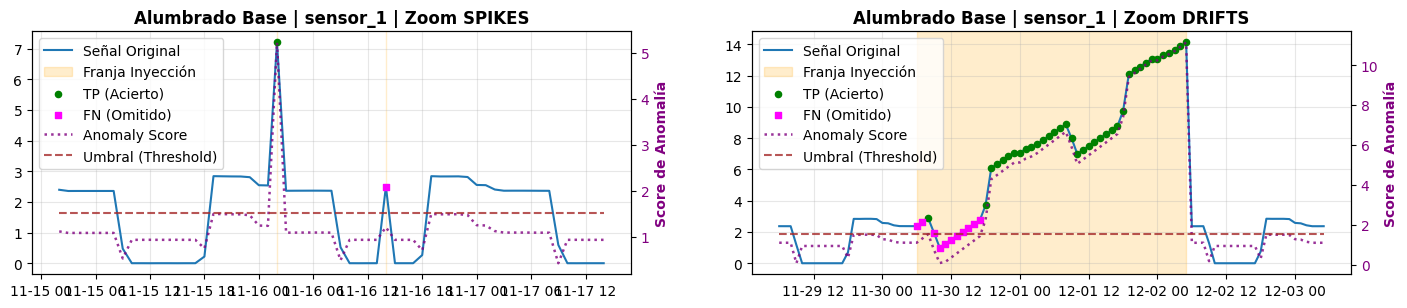

In [49]:
display(extraer_ranking_completo(job_uuids["Alumbrado"], "Alumbrado", "Zero-Shot"))
graficar_diagnostico_zoom(job_uuids["Alumbrado"], "Alumbrado Base", dias_zoom=1)

#### 5.1.2. ETT (Multivariante)

,Modelo,AUC-PR,Precision,Recall,F1-Score,TP,FP,FN,Fase
0,MULTI_PCA_SOFTIMPUTE,0.6108,0.5526,0.42,0.4773,21,17,29,Zero-Shot
1,MULTI_SAITS,0.3982,0.1534,0.54,0.2389,27,149,23,Zero-Shot
2,MULTI_AUTOENCODER_SOFTIMPUTE,0.3497,0.3947,0.30,0.3409,15,23,35,Zero-Shot


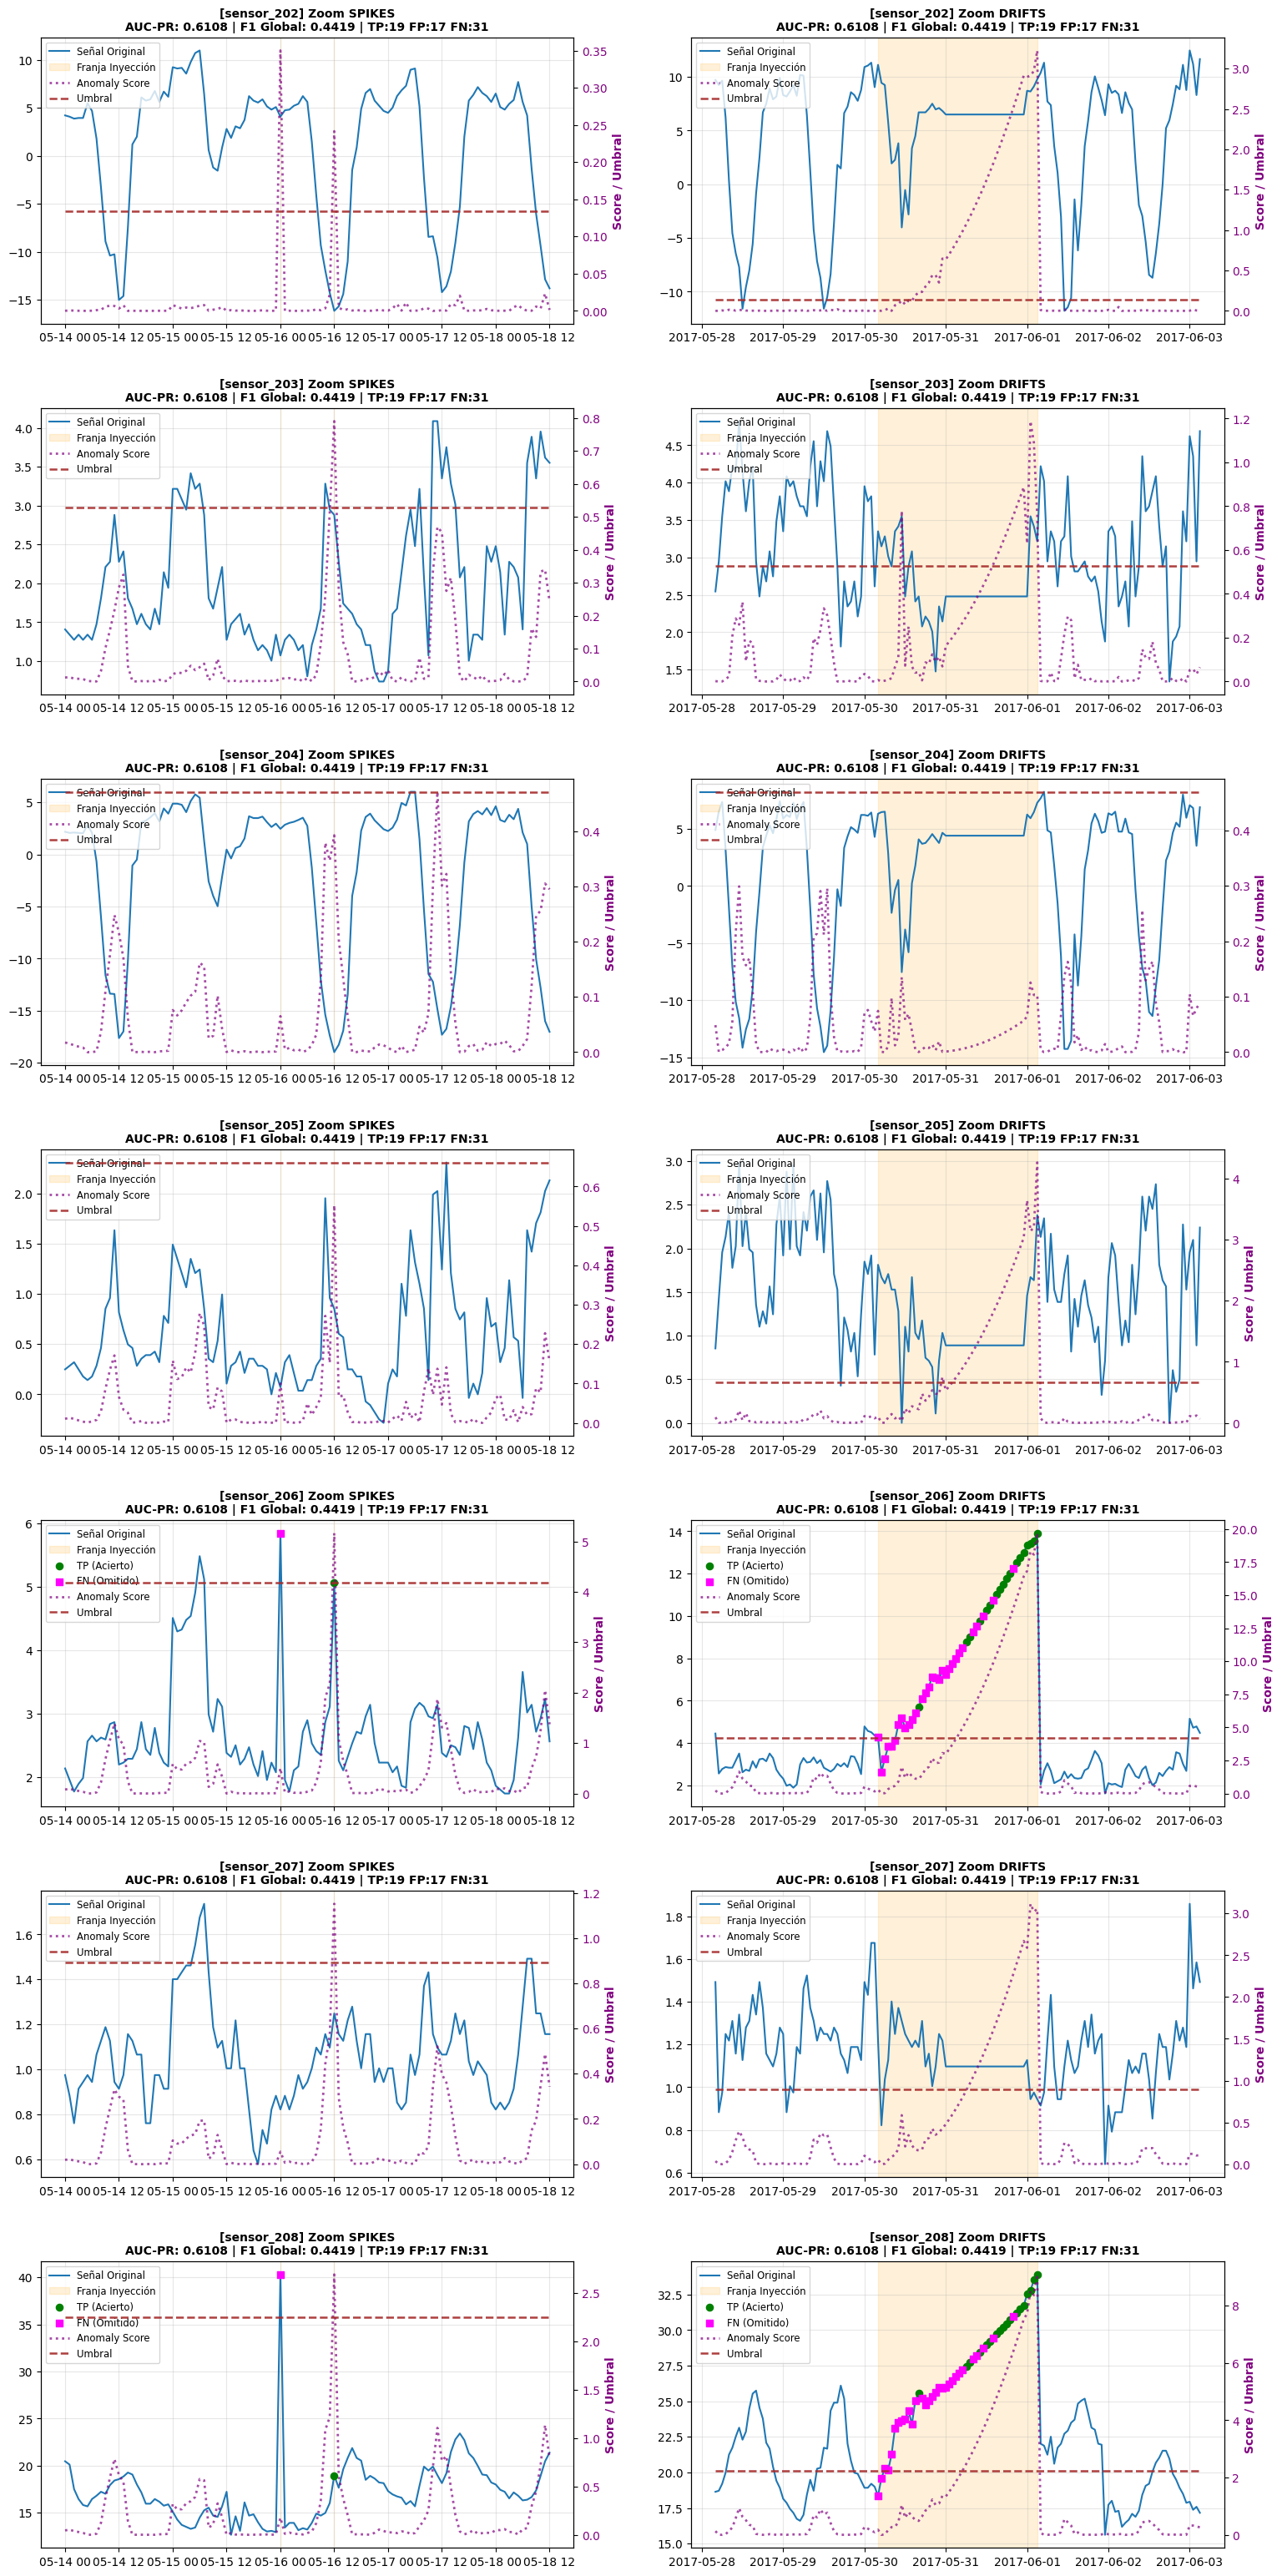

In [18]:
display(extraer_ranking_completo(job_uuids["ETTh1"], "ETT", "Zero-Shot"))
graficar_diagnostico_zoom(job_uuids["ETTh1"], "ETT Base", dias_zoom=2)

### 5.2. Torneo HPO y Feature Engineering

<div style="text-align: justify;">

Se exponen a continuación los rankings de los modelos evaluados en el torneo completo, ya con HPO y Feature Engineering, así como las gráficas construidas para su visualización, para cada uno de los dos datasets de evaluación.

</div>

#### 5.2.1 Alumbrado Público (Univariante)

,Modelo,AUC-PR,Precision,Recall,F1-Score,TP,FP,FN,Fase
0,UNI_LIGHTGBM_TABULAR,0.9573,1.0,0.66,0.7952,33,0,17,HPO
1,ZSCORE_LINEAR,0.7904,1.0,0.78,0.8764,39,0,11,HPO
2,UNI_IFOREST_LIGHTGBM,0.2633,1.0,0.04,0.0769,2,0,48,HPO


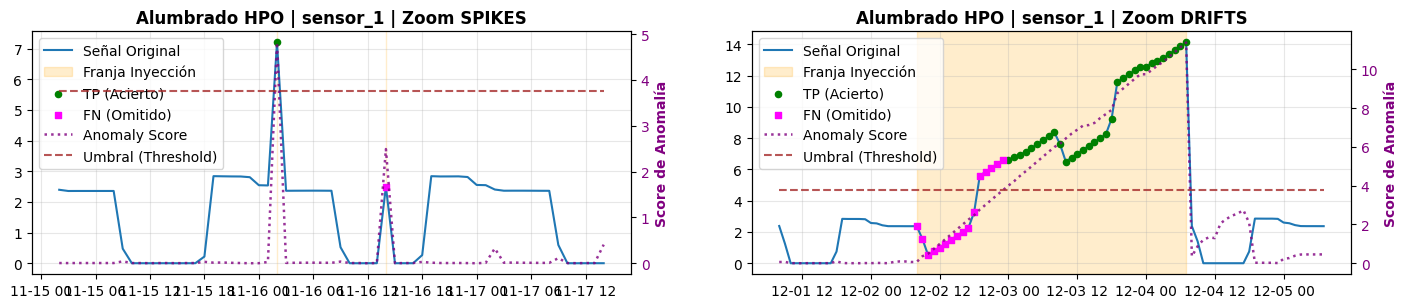

In [86]:
display(extraer_ranking_completo(hpo_job_uuids["Alumbrado"], "Alumbrado", "HPO"))
graficar_diagnostico_zoom(hpo_job_uuids["Alumbrado"], "Alumbrado HPO", dias_zoom=1)

#### 5.2.2. ETT (Multivariante)

,Modelo,AUC-PR,Precision,Recall,F1-Score,TP,FP,FN,Fase
0,MULTI_AUTOENCODER_SOFTIMPUTE_OPTIMIZED,0.8349,0.5065,0.78,0.6142,39,38,11,HPO


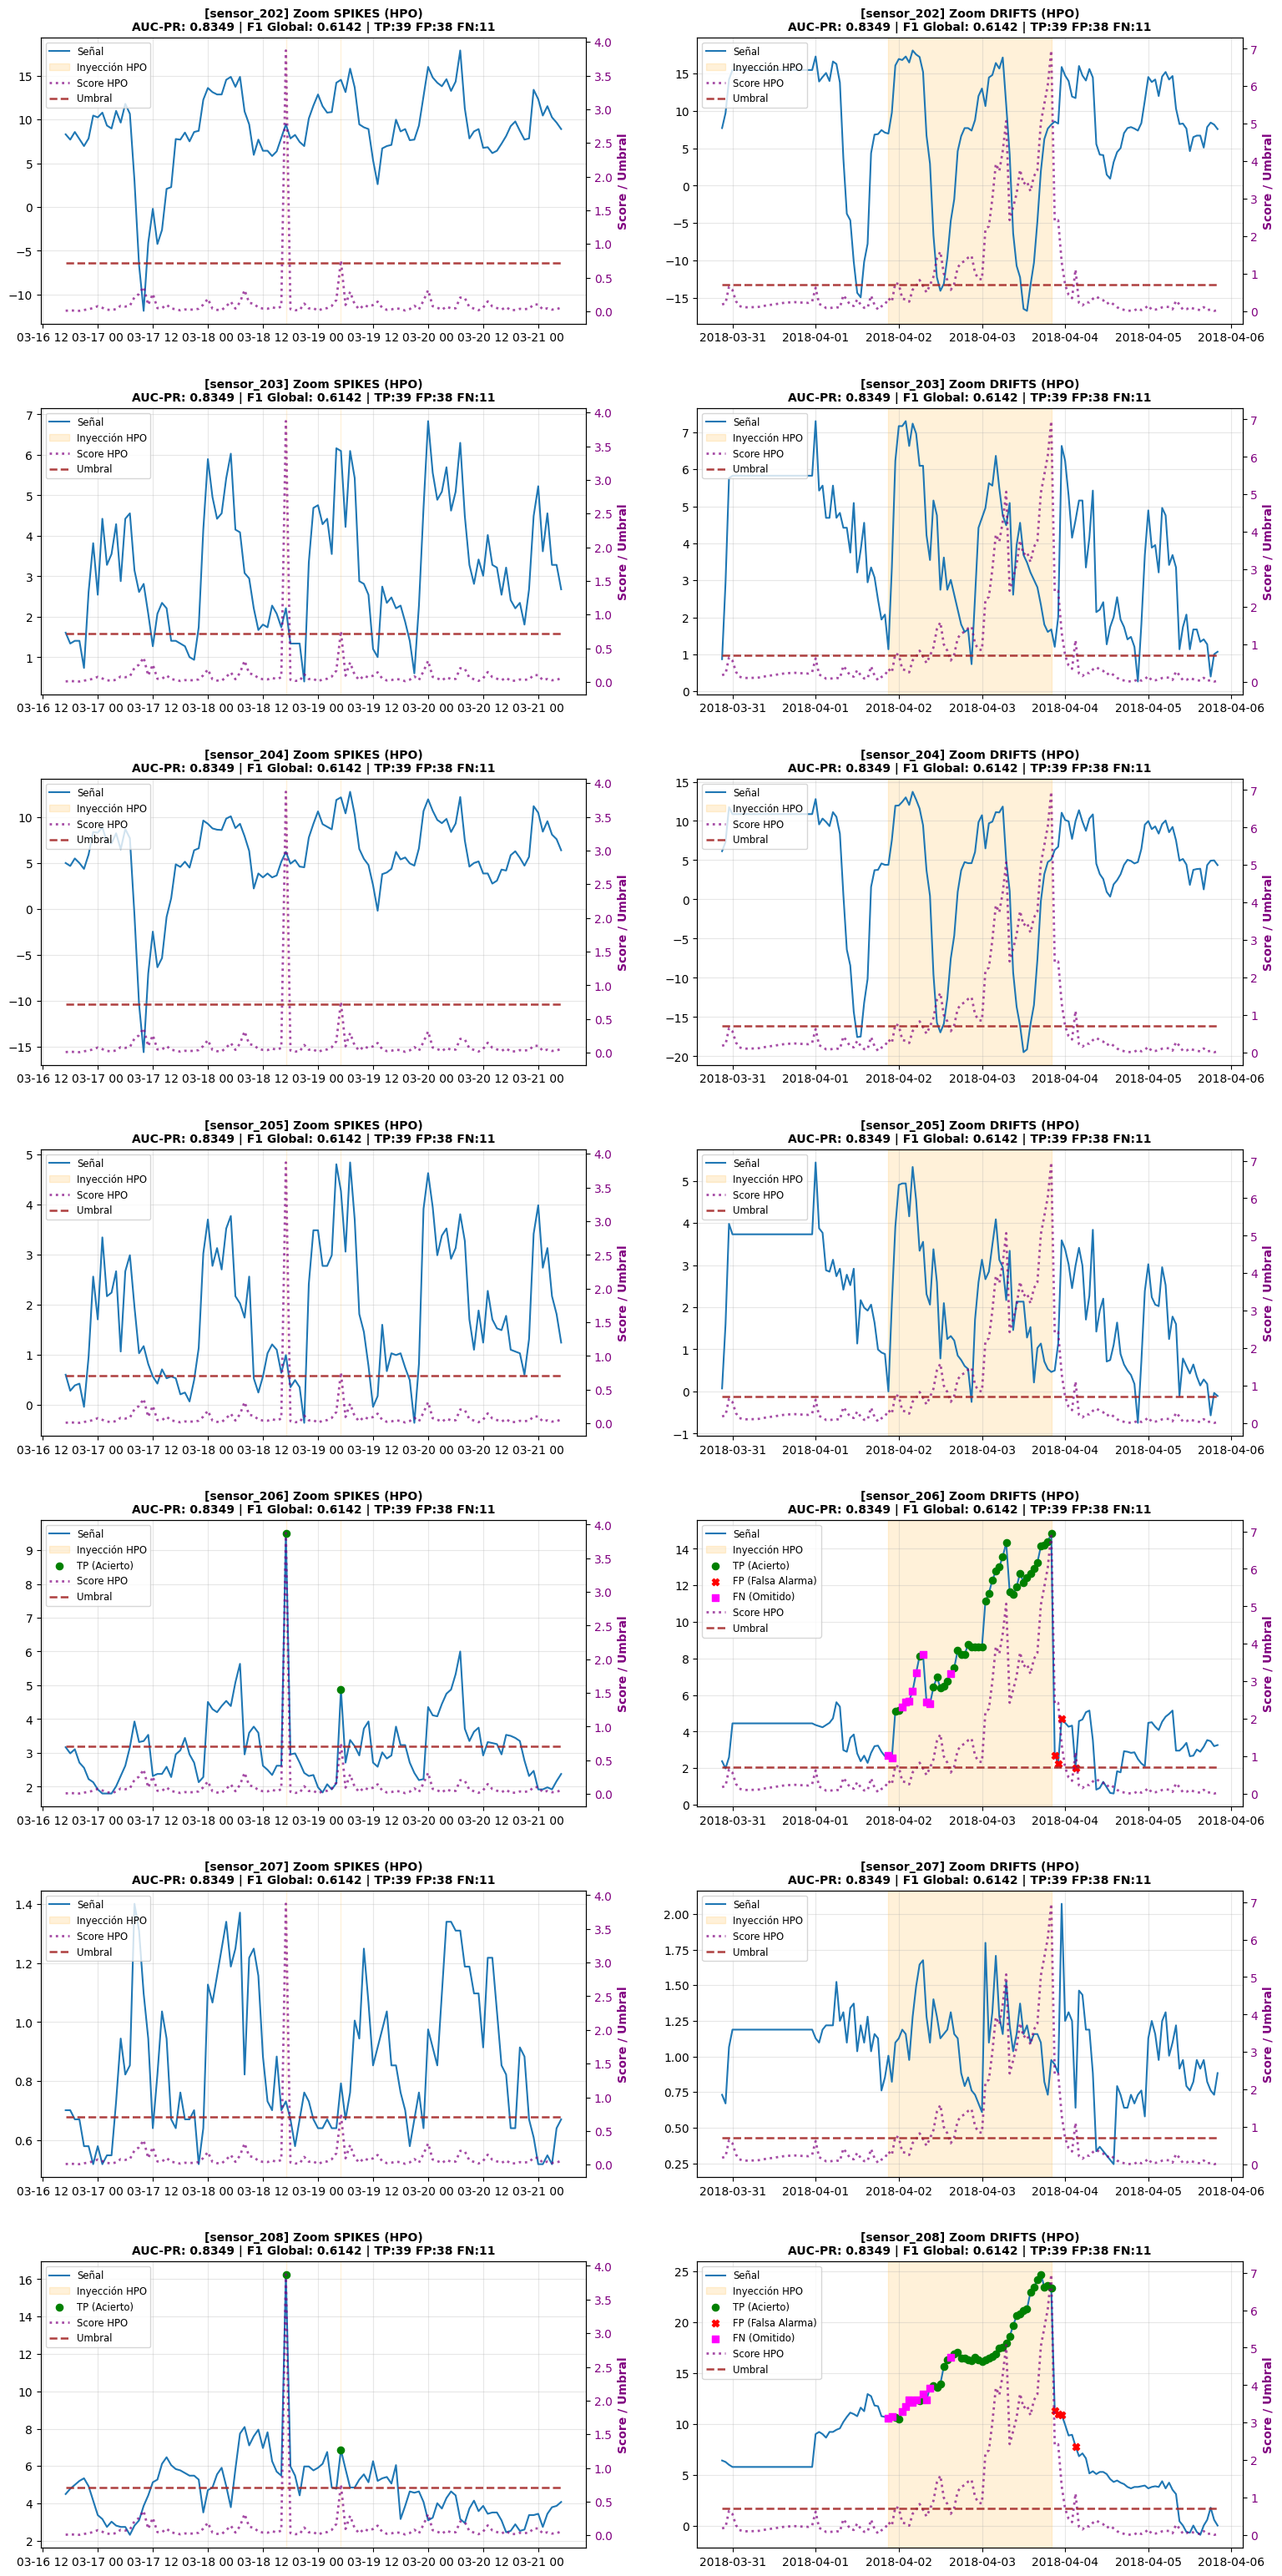

In [16]:
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt

API_BASE = "http://127.0.0.1:8000/api/v1"

def extraer_metricas_hpo_multivariante_real(job_id, dataset_name, fase="HPO"):
    """
    Extrae la métrica AUC-PR optimizada y calcula TP, FP, FN a nivel GLOBAL (por timestamp),
    evitando multiplicar los Falsos Positivos en las señales sanas.
    """
    try:
        # 1. Obtener JSON del summary
        resp_sum = requests.get(f"{API_BASE}/jobs/{job_id}/result/summary", timeout=15)
        if resp_sum.status_code == 200:
            sandbox = resp_sum.json().get("summary", {}).get("sandbox", {})
        else:
            resp_sum = requests.get(f"{API_BASE}/jobs/{job_id}", timeout=15)
            resp_sum.raise_for_status()
            sandbox = resp_sum.json().get("result", {}).get("summary", {}).get("sandbox", {})
        
        # 2. Extraer metadatos y AUC-PR
        winner_profile = sandbox.get("winner_profile", {})
        model_name = winner_profile.get("winner_model_name", sandbox.get("winner_model", "Modelo_Desconocido"))
        
        hpo_runs = sandbox.get("hpo", {}).get("hpo_runs", [])
        auc_pr_hpo = hpo_runs[0].get("best_value", 0.0) if hpo_runs and isinstance(hpo_runs, list) else 0.0
        
        manifest = sandbox.get("competition_metadata", {}).get("test_scenario", {}).get("injection_manifest", [])
        
        # 3. Obtener predicciones finales optimizadas
        url_ts = f"{API_BASE}/jobs/{job_id}/result?offset=0&limit=20000"
        resp_ts = requests.get(url_ts, timeout=30)
        resp_ts.raise_for_status()
        
        result_data = resp_ts.json()
        ts_list = result_data.get("timeseries_data", [])
        if not ts_list:
            ts_list = result_data.get("result", {}).get("inferences", {}).get("timeseries_data", [])
            
        df_ts = pd.DataFrame(ts_list)
        if df_ts.empty: return pd.DataFrame()
        df_ts['timestamp'] = pd.to_datetime(df_ts['timestamp'])
        
        # 4. COLAPSAR A NIVEL GLOBAL (Un veredicto por Timestamp)
        df_global = df_ts[['timestamp', 'is_outlier']].drop_duplicates(subset=['timestamp']).sort_values('timestamp').reset_index(drop=True)
        
        # Ground Truth Global: Es anomalía si *cualquier* inyección ocurrió en este índice
        gt_mask = np.zeros(len(df_global), dtype=bool)
        for inj in manifest:
            start = inj.get("start_idx")
            size = inj.get("size_steps", 1)
            gt_mask[start:start+size] = True
            
        pred_mask = df_global["is_outlier"].fillna(False).astype(bool).values
        
        total_tp = (gt_mask & pred_mask).sum()
        total_fp = (~gt_mask & pred_mask).sum()
        total_fn = (gt_mask & ~pred_mask).sum()
            
        precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0.0
        recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0.0
        f1_score = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
        
        # 5. Generar DataFrame Final
        results_data = [{
            "Modelo": f"{model_name}_OPTIMIZED",
            "AUC-PR": round(auc_pr_hpo, 4),
            "Precision": round(precision, 4),
            "Recall": round(recall, 4),
            "F1-Score": round(f1_score, 4),
            "TP": int(total_tp),
            "FP": int(total_fp),
            "FN": int(total_fn),
            "Fase": fase
        }]
        return pd.DataFrame(results_data)
        
    except Exception as e:
        print(f" Error procesando las métricas HPO Reales de {dataset_name}: {e}")
        return pd.DataFrame()


def graficar_diagnostico_hpo_multivariante_real(job_id, dataset_name, dias_zoom=3):
    """
    Grafica el diagnóstico post-HPO.
    Calcula TP/FP/FN a nivel global para el subtítulo, y dibuja los marcadores visuales
    EXCLUSIVAMENTE en los sensores que recibieron inyecciones (ocultándolos en los sanos).
    """
    try:
        # 1. Metadatos y manifiesto
        resp_sum = requests.get(f"{API_BASE}/jobs/{job_id}/result/summary", timeout=15)
        if resp_sum.status_code == 200:
            sandbox = resp_sum.json().get("summary", {}).get("sandbox", {})
        else:
            resp_sum = requests.get(f"{API_BASE}/jobs/{job_id}", timeout=15)
            sandbox = resp_sum.json().get("result", {}).get("summary", {}).get("sandbox", {})
            
        manifest = sandbox.get("competition_metadata", {}).get("test_scenario", {}).get("injection_manifest", [])
        hpo_runs = sandbox.get("hpo", {}).get("hpo_runs", [])
        global_auc_pr = hpo_runs[0].get("best_value", 0.0) if hpo_runs and isinstance(hpo_runs, list) else 0.0

        spikes_info, drifts_info = [], []
        for inj in manifest:
            t_type = inj.get("type")
            start = inj.get("start_idx")
            size = inj.get("size_steps", 1)
            info = {"start": start, "end": start + size - 1, "columns": inj.get("columns", []), "cols": inj.get("columns", [])}
            if t_type == "spike": spikes_info.append(info)
            elif t_type == "drift": drifts_info.append(info)

        def is_impacted(inj_info, sig_name):
            cols = inj_info.get("columns", inj_info.get("cols", []))
            return not cols or "all_signals" in cols or sig_name in cols

        # 2. Obtener Datos Temporales Completos
        resp_ts = requests.get(f"{API_BASE}/jobs/{job_id}/result?offset=0&limit=20000", timeout=30)
        result_data = resp_ts.json()
        ts_list = result_data.get("timeseries_data", [])
        if not ts_list:
            ts_list = result_data.get("result", {}).get("inferences", {}).get("timeseries_data", [])
            
        df_ts = pd.DataFrame(ts_list)
        if df_ts.empty: return
        df_ts['timestamp'] = pd.to_datetime(df_ts['timestamp'])
        
        # 3. CÁLCULO DE MÉTRICAS GLOBALES (Para los títulos)
        df_global = df_ts[['timestamp', 'is_outlier']].drop_duplicates(subset=['timestamp']).sort_values('timestamp').reset_index(drop=True)
        global_gt_mask = np.zeros(len(df_global), dtype=bool)
        for inj in manifest:
            start = inj.get("start_idx")
            size = inj.get("size_steps", 1)
            global_gt_mask[start:start+size] = True
            
        pred_mask = df_global['is_outlier'].fillna(False).astype(bool).values
        global_tp = (global_gt_mask & pred_mask).sum()
        global_fp = (~global_gt_mask & pred_mask).sum()
        global_fn = (global_gt_mask & ~pred_mask).sum()
        
        g_prec = global_tp / (global_tp + global_fp) if (global_tp + global_fp) > 0 else 0.0
        g_rec = global_tp / (global_tp + global_fn) if (global_tp + global_fn) > 0 else 0.0
        global_f1 = 2 * g_prec * g_rec / (g_prec + g_rec) if (g_prec + g_rec) > 0 else 0.0

        metrics_subtitle = f"AUC-PR: {global_auc_pr:.4f} | F1 Global: {global_f1:.4f} | TP:{global_tp} FP:{global_fp} FN:{global_fn}"

        # 4. GRAFICADO POR SEÑAL
        signals = sorted(df_ts['signal_id'].unique())
        fig, axes = plt.subplots(len(signals), 2, figsize=(16, 4.5 * len(signals)))
        if len(signals) == 1: axes = [axes]
            
        for i, sig_id in enumerate(signals):
            ax_spike, ax_drift = axes[i][0], axes[i][1]
            sig_name = f"sensor_{sig_id}"
            window = pd.Timedelta(days=dias_zoom)
            
            df_sig = df_ts[df_ts['signal_id'] == sig_id].copy().sort_values('timestamp').reset_index(drop=True)
            df_sig['gt_outlier'] = global_gt_mask
            df_sig['is_outlier'] = pred_mask
            
            # Comprobar si esta señal específica recibió alguna inyección
            is_targeted = any(is_impacted({"cols": inj.get("columns", inj.get("cols", []))}, sig_name) for inj in manifest)

            def plot_zone(ax, df_zone, zones_info, base_title):
                ax.plot(df_zone['timestamp'], df_zone['original_value'], color='#1f77b4', linewidth=1.5, label="Señal")
                
                # Sombrear inyecciones
                added_bg_label = False
                for t_s, t_e, impacted in zones_info:
                    label = 'Inyección HPO' if not added_bg_label else None
                    ax.axvspan(t_s, t_e, color='orange', alpha=0.15, label=label)
                    added_bg_label = True

                # SOLUCIÓN: Solo dibujamos TP/FP/FN si la señal estaba directamente dañada
                if is_targeted:
                    tps = df_zone[(df_zone['gt_outlier'] == True) & (df_zone['is_outlier'] == True)]
                    fps = df_zone[(df_zone['gt_outlier'] == False) & (df_zone['is_outlier'] == True)]
                    fns = df_zone[(df_zone['gt_outlier'] == True) & (df_zone['is_outlier'] == False)]
                    
                    if not tps.empty: ax.scatter(tps['timestamp'], tps['original_value'], color='green', marker='o', s=35, label='TP (Acierto)', zorder=5)
                    if not fps.empty: ax.scatter(fps['timestamp'], fps['original_value'], color='red', marker='X', s=35, label='FP (Falsa Alarma)', zorder=5)
                    if not fns.empty: ax.scatter(fns['timestamp'], fns['original_value'], color='magenta', marker='s', s=35, label='FN (Omitido)', zorder=5)
                
                handles1, labels1 = ax.get_legend_handles_labels()
                
                # Eje secundario de Score (se pinta siempre)
                if 'anomaly_score' in df_zone.columns and not df_zone['anomaly_score'].isna().all():
                    ax2 = ax.twinx()
                    ax2.plot(df_zone['timestamp'], df_zone['anomaly_score'], color='purple', linestyle=':', linewidth=2, alpha=0.7, label="Score HPO")
                    
                    th_col = 'threshold' if 'threshold' in df_zone.columns else ('dynamic_threshold' if 'dynamic_threshold' in df_zone.columns else None)
                    if th_col and th_col in df_zone.columns and not df_zone[th_col].isna().all():
                        ax2.plot(df_zone['timestamp'], df_zone[th_col], color='brown', linestyle='--', linewidth=1.8, alpha=0.9, label="Umbral")
                    
                    ax2.set_ylabel('Score / Umbral', color='purple', fontweight='bold')
                    ax2.tick_params(axis='y', labelcolor='purple')
                    
                    handles2, labels2 = ax2.get_legend_handles_labels()
                    by_label = dict(zip(labels1 + labels2, handles1 + handles2))
                    ax.legend(by_label.values(), by_label.keys(), loc='upper left', fontsize='small')
                else:
                    by_label = dict(zip(labels1, handles1))
                    if by_label: ax.legend(by_label.values(), by_label.keys(), loc='upper left', fontsize='small')

                # Subtítulo Global idéntico para todos los sensores
                ax.set_title(f"{base_title}\n{metrics_subtitle}", fontweight='bold', fontsize=10)
                ax.grid(True, alpha=0.3)

            # --- ZOOM SPIKES ---
            if spikes_info:
                min_idx, max_idx = min(s["start"] for s in spikes_info), max(s["end"] for s in spikes_info)
                if max_idx < len(df_sig):
                    t_min, t_max = df_sig.iloc[min_idx]['timestamp'], df_sig.iloc[max_idx]['timestamp']
                    spk_zones = [(df_sig.iloc[s["start"]]['timestamp'], df_sig.iloc[s["end"]]['timestamp'], is_impacted(s, sig_name)) for s in spikes_info]
                    df_spk = df_sig[(df_sig['timestamp'] >= t_min - window) & (df_sig['timestamp'] <= t_max + window)]
                    plot_zone(ax_spike, df_spk, spk_zones, f"[{sig_name}] Zoom SPIKES (HPO)")
                else: ax_spike.set_title(f"[{sig_name}] Fuera de rango")
            else: ax_spike.set_title(f"[{sig_name}] Sin Spikes")
                
            # --- ZOOM DRIFTS ---
            if drifts_info:
                min_idx, max_idx = min(d["start"] for d in drifts_info), max(d["end"] for d in drifts_info)
                if max_idx < len(df_sig):
                    t_min, t_max = df_sig.iloc[min_idx]['timestamp'], df_sig.iloc[max_idx]['timestamp']
                    drf_zones = [(df_sig.iloc[d["start"]]['timestamp'], df_sig.iloc[d["end"]]['timestamp'], is_impacted(d, sig_name)) for d in drifts_info]
                    df_drf = df_sig[(df_sig['timestamp'] >= t_min - window) & (df_sig['timestamp'] <= t_max + window)]
                    plot_zone(ax_drift, df_drf, drf_zones, f"[{sig_name}] Zoom DRIFTS (HPO)")
                else: ax_drift.set_title(f"[{sig_name}] Fuera de rango")
            else: ax_drift.set_title(f"[{sig_name}] Sin Drifts")

        plt.tight_layout(pad=3.0)
        plt.show()
    except Exception as e:
        print(f" Error al generar gráficas HPO de {dataset_name}: {e}")

display(extraer_metricas_hpo_multivariante_real(hpo_job_uuids["ETTh1"], "ETTh1", "HPO"))
graficar_diagnostico_hpo_multivariante_real(hpo_job_uuids["ETTh1"], "ETTh1", dias_zoom=2)

## 6. Conclusiones <a id="conclusiones"></a>

<div style="text-align: justify;">

En la siguiente sección se exponen las conclusiones de los resultados obtenidos en las pruebas realizadas sobre los dos conjuntos de datos. El flujo de ejecución en el entorno Sandbox es: inyección de daños en un copia del dataset original; evaluación de los daños mediante los candidatos seleccionados (con o sin HPO); proclamción de un ganador de acuerdo con la métrica elegida. En este caso, para la tarea de detección de anoamlías, se ha empleado el Área Bajo la Curva de Precisión y Recall (AUC-PR) como la métrica decisiva. A diferencia de métricas discretas como el F1-Score, que está fuertemente relacionado con la calibración del umbralizador final y enmascara el rendimiento real del modelo, la AUC-PR evalúa la capacidad del predictor para ordenar y separar las densidades de probabilidad normales de las anómalas. Esto garantiza una optimización matemática suave, aislando la calidad del modelo de las reglas de binarización posteriores.

</div>

### 6.1. Alumbrado Público (Regular)

<div style="text-align: justify;">

Para el dataset de alumbrado hemos comparado tres modelos diferentes: el método estadístico Z-Score, el algoritmo Isolation Forest modificado para un escenario univariante, y el método basado en Gradient Boosting LightGBM.

En primer lugar, destaca el colapso de los modelos basados en árboles (tanto LightGBM como Isolation Forest) en el torneo base cuando se desactiva por completo el módulo de ingeniería de características (`enable_feature_engineering = False`). Al carecer de un contexto histórico o de variables exógenas, ambos algoritmos resultan completamente ciegos, obteniendo un valor de AUC-PR, precisión y recall de exactamente 0.0000.

En cuanto a Isolation Forest, el algoritmo confirma su bajo rendimiento en este tipo de entornos univariantes. Obtiene un valor nulo de 0.0000 en el torneo base y alcanza únicamente un 0.3247 de AUC-PR tras la fase de optimización de hiperparámetros (HPO). A pesar de que este modelo soporta de forma nativa trabajar con una sola variable, despliega su verdadero potencial en entornos multivariantes; las series con una única señal requieren una ingeniería de características extremadamente sólida para que los cortes del árbol sean efectivos, una condición que parece que no cumplimos en el entorno actual.

Por otro lado, el método estadístico Z-Score demuestra un funcionamiento muy razonable, ofreciendo un equilibrio excelente entre precisión y coste computacional. Al basarse en la desviación típica global de la señal, captura con facilidad las rupturas de escala masivas de los picos, manteniendo un AUC-PR constante de 0.8165 y un recall de 0.7800. Sin embargo, su gran limitación es que es totalmente incapaz de identificar anomalías contextuales. Al evaluar los datos de forma global, el Z-Score es ciego ante el pico diurno inyectado, ya que el valor absoluto de consumo a mediodía no rompe los límites de la desviación estándar de todo el histórico.

Una vez que el orquestador activa la selección óptima de características y la HPO, el escenario cambia por completo. En este caso, se seleccionan los lags de 24 y 48 horas de manera automática bajo los parámetros por defecto de un máximo de 5 características y un mínimo del 3% de importancia relativa, como se muestra en el extracto del JSON de respuesta: 

```json
"feature_selection": {
        "feature_config": {
          "lags": [
            24,
            48
          ]
        },
        "importances": {
          "sensor_1__lag_24h": 0.8724404233088804,
          "sensor_1__lag_48h": 0.11364433828647973,
          "sensor_1__lag_1h": 0.003931752440492536,
          "__cal_cos_hour": 0.002469415343925946,
          "sensor_1__lag_72h": 0.002147506181845066,
          "sensor_1__rolling_mean_3h": 0.0008420957803083999,
          "sensor_1__lag_168h": 0.0007305346724454663,
          "sensor_1__rolling_mean_12h": 0.0005270360169919589,
          "sensor_1__rolling_mean_24h": 0.0005265897379511575,
          "sensor_1__rolling_std_24h": 0.0005240758764629839,
          "sensor_1__lag_12h": 0.00035181548484739883,
          "sensor_1__rolling_std_12h": 0.00033312265873176,
          "sensor_1__rolling_std_3h": 0.0003096732013336029,
          "sensor_1__lag_3h": 0.00023912248421004284,
          "sensor_1__rolling_std_6h": 0.00021991241515378597,
          "sensor_1__lag_6h": 0.0001985925199054278,
          "sensor_1__rolling_mean_6h": 0.00019018346431626403,
          "__cal_hour": 0.00014092321836462924,
          "sensor_1__lag_2h": 0.00009091838144777777,
          "__cal_cos_day_of_week": 0.0000818497774584699,
          "__cal_sin_day_of_week": 0.000031847934188273764,
          "__cal_day_of_week": 0.000017249472928782928,
          "__cal_sin_hour": 0.0000110213413301948,
          "__cal_is_weekend": 0
        },
        "kept": [
          "sensor_1__lag_24h",
          "sensor_1__lag_48h"
        ],
        "dropped": [
          "sensor_1__lag_1h",
          "sensor_1__lag_2h",
          "sensor_1__lag_3h",
          "sensor_1__lag_6h",
          "sensor_1__lag_12h",
          "sensor_1__lag_72h",
          "sensor_1__lag_168h",
          "sensor_1__rolling_mean_3h",
          "sensor_1__rolling_std_3h",
          "sensor_1__rolling_mean_6h",
          "sensor_1__rolling_std_6h",
          "sensor_1__rolling_mean_12h",
          "sensor_1__rolling_std_12h",
          "sensor_1__rolling_mean_24h",
          "sensor_1__rolling_std_24h",
          "__cal_hour",
          "__cal_day_of_week",
          "__cal_is_weekend",
          "__cal_sin_hour",
          "__cal_cos_hour",
          "__cal_sin_day_of_week",
          "__cal_cos_day_of_week"
        ]
      },
```

Así, el modelo LightGBM se corona como el ganador del torneo con una AUC-PR de 0.9448. Gracias a este contexto temporal, el modelo aprende el patrón diario de la red y le asigna una puntuación de anomalía significativamente más alta al pico diurno.

Por último, cabe destacar que, a pesar de que LightGBM supera a Z-Score en términos de AUC-PR, las métricas absolutas de precisión, recall y F1-Score siguen mostrando mejores valores en el método estadístico. Esto se debe a que estas tres últimas métricas entran en juego solo tras la acción del umbralizador final, evidenciando que el criterio actual es demasiado restrictivo para el residuo continuo generado por LightGBM. Este desfase pone de manifiesto que el verdadero margen de mejora del sistema no se encuentra en la capacidad predictiva del modelo, sino en la calibración y el ajuste fino del propio umbralizador, siendo este el punto clave donde concentrar los esfuerzos futuros para conseguir unos mejores resultados.

</div>

### 6.2. ETTh1 (Electricity Transformer Temperature)

<div style="text-align: justify;">


</div>

<div style="text-align: justify;">

Para el dataset de ETT (Electricity Transformer Temperature) hemos comparado tres modelos: el método de reducción de la dimensionalidad PCA, un modelo de nuestra arquitectura Autoencoder y el modelo de la arquitectura SAITS.

El análisis de los resultados obtenidos en el torneo base sitúa a PCA como el ganador inicial con un AUC-PR de 0.6108, el modelo SAITS obtuvo 0.3982, y finalmente el Autoencoder 0.3497. Este comportamiento muestra que, ante configuraciones no optimizadas, los métodos más sencillos muestran mayor capacidad de aislar eventos anómalos que los modelos más complejos en este conjunto de datos.

Sin embargo, el hallazgo más relevante se observa al analizar las métricas discretas, donde se observa un comportamiento del umbralizador opuesto al escenario univariante. Mientras que en el caso de Alumbrado Público el umbralizador operaba de forma restrictiva (generando falsos negativos, mayor precisión, menor recall), en el entorno multivariante exhibe un comportamiento altamente permisivo (generando falsos positivos, mayor recall, menor precisión). Este fenómeno responde a la morfología de la distribución de las punutaciones de anomalía. Al evaluar las señales de forma combinada, el ruido residual acumulado por los modelos tiende a suavizar la función de probabilidad. Al aplicar las umbralizaciones dinámicas con sus parámetros por defecto, el sistema calcula una línea de defensa operativa demasiado baja, especialmente en el caso de SAITS, donde observamso un número de falsos positivos mucho mayor que con el resto de modelos (149).

Ya una vez ejecutamos el torneo HPO, observamos una mejora sustancial. Para poder verificar como se comporta el motor de optimización se ha eliminado del pool de modelos a PCA, ganador del torneo base, ya que no se encuentra dentro de los modelos incluidos en el motor de optimización. De esta manera, el modelo ganador de un nuevo torneo base, donde se han desplazado las anomalías 50 posiciones más adelante, será el que entre en el motor de optimización. En este nuevo torneo, se ha erigido como ganador el modelo de la arquitectura Autoencoder, que tras entrar en el motor de optimización, ha obtenido una AUC-PR en su mejor configuración de 0.8349. Las métricas discretas muestran una mejora sustancial, sin embargo siguen exhibiendo un mayor recall que precisión, al igual que el torneo base (salvo PCA). Atendiendo a las gráficas generadas, en los puntos posteriores a las anomalías inyectadas se asignan puntuaciones de anomalía elevadas, que se sitúan por encima del umbral y son marcados como anomalías a pesar de que teóricamente no lo sean, aunque esos FP son aceptables dado que se son colindantes a la inyección de daño sintético. Un aspecto muy importante a destacar es la dependencia de estructuras tan complejas con el volumen de datos del que disponen. Estructuras como redes neuronales complejas, más aún arquitecturas como SAITS (basada en transformers), necesitan más datos de los que se les ha proporcionado en esta prueba. Sin embargo, dado que estas están sujetas al hardware del que se dispone, sin aceleración por GPU, y dada la complejidad del sistema desplegado, se ha optado por emplear volúmenes de datos menores, siendo conocedores del sobreajuste que sufren arquitecturas tan complejas a los datos de entrenamiento si no se les proporciona un volumen suficiente para lograr la generalización objetivo.

</div>